### **2DCNN**

Starting training (sensor-only data)...
Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - accuracy: 0.1119 - loss: 2.5708 - val_accuracy: 0.0629 - val_loss: 2.3987 - learning_rate: 1.0000e-04
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 257ms/step - accuracy: 0.4253 - loss: 2.2188 - val_accuracy: 0.1467 - val_loss: 2.1226 - learning_rate: 1.0000e-04
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 255ms/step - accuracy: 0.6657 - loss: 1.9504 - val_accuracy: 0.3206 - val_loss: 1.9309 - learning_rate: 1.0000e-04
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 246ms/step - accuracy: 0.7388 - loss: 1.7391 - val_accuracy: 0.3551 - val_loss: 1.8156 - learning_rate: 1.0000e-04
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 250ms/step - accuracy: 0.8072 - loss: 1.5644 - val_accuracy: 0.4205 - val_loss: 1.7372 - learning_rate: 1.0000e-04
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - accuracy: 0.8459 - loss: 1.4093 - val_accuracy: 0.4747 - val_loss: 1.6660 - learning_rate: 1.0000e-04


Training complete. Model saved to brake_diagnosis_2dcnn_sensor_only.h5, metadata saved to meta_sensor_only.pkl


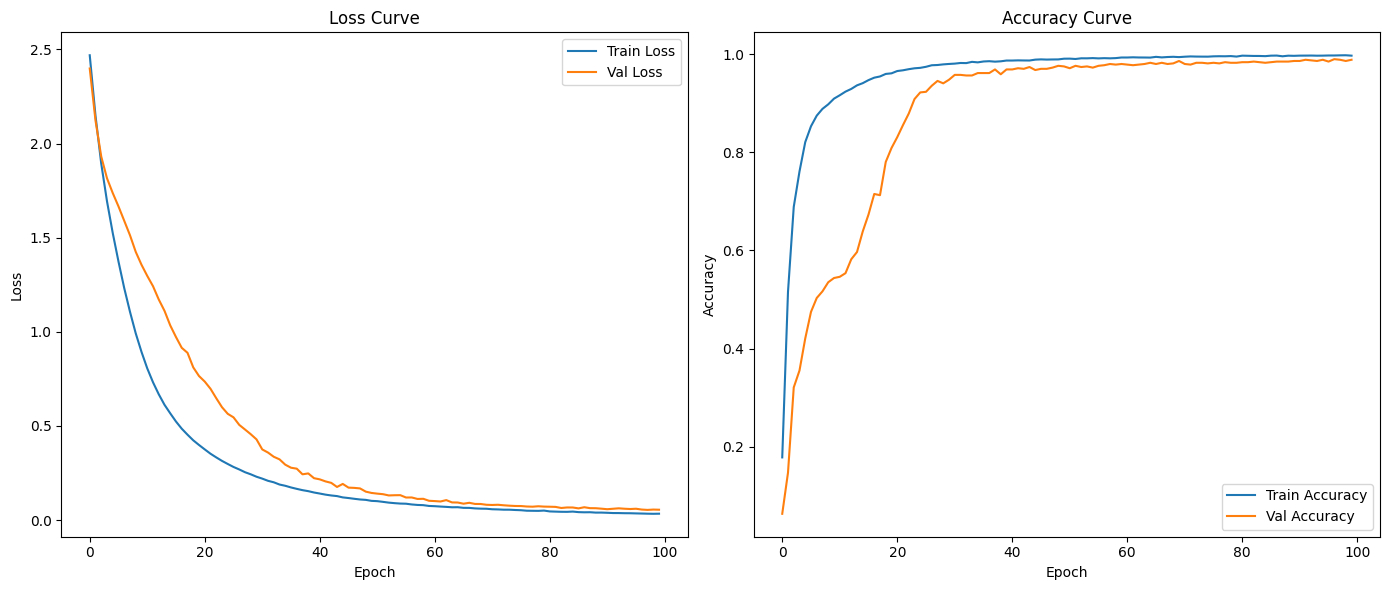

Evaluation on validation set:
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
=== Validation Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       360
           1       1.00      0.95      0.97        55
           2       1.00      1.00      1.00        45
           3       0.98      1.00      0.99        57
           4       1.00      0.96      0.98        47
           5       0.98      1.00      0.99        45
           6       1.00      0.97      0.98        59
           7       1.00      1.00      1.00        52
           8       1.00      1.00      1.00        50
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00         4

    accuracy                           0.99       811
   macro avg       1.00      0.99      0.99       811
weighted avg       0.99      0.99      0.99       811



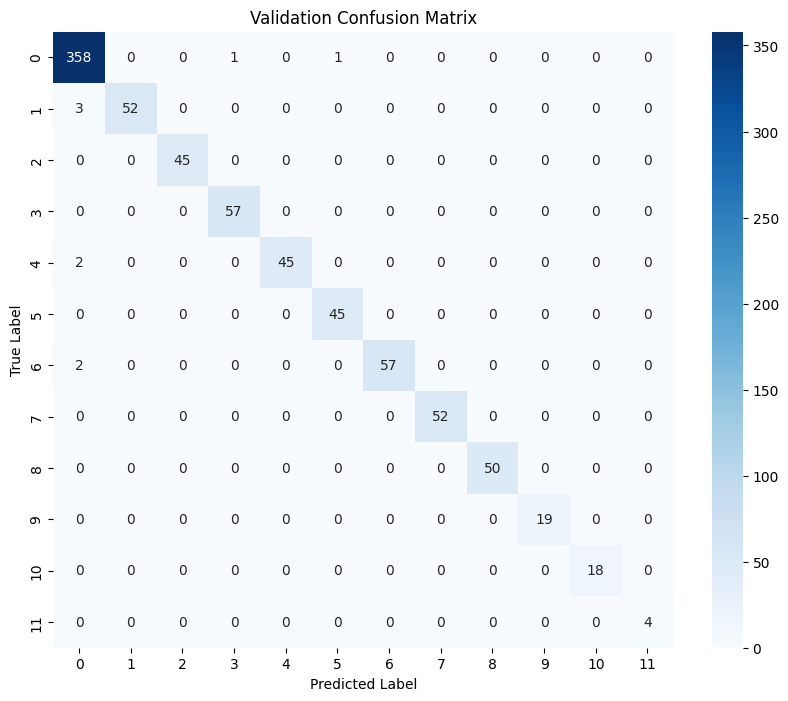

Starting test evaluation...
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
=== Test Classification Report ===
              precision    recall  f1-score   support

           0       0.66      0.72      0.69       593
           1       0.00      0.00      0.00       104
           2       0.34      0.10      0.15       105
           3       0.00      0.00      0.00         0
           4       0.34      0.53      0.42       103
           5       0.48      0.22      0.30        96
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0

    accuracy                           0.51      1001
   macro avg       0.15      0.13      0.13      1001
weighted avg       0.51      0.51      0.50      1001



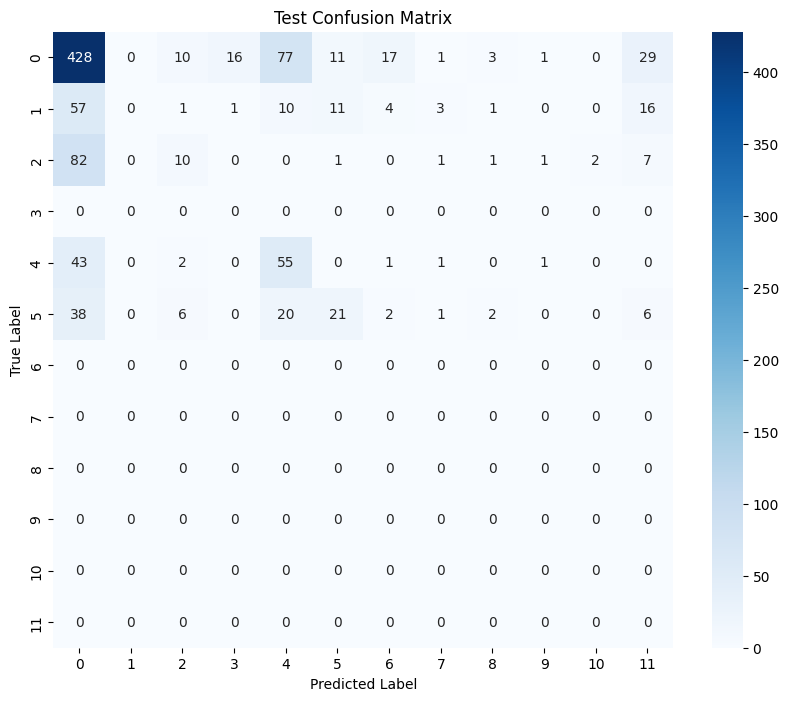

Test evaluation complete.


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# ------------------ Path configuration ------------------
TRAIN_PATH = r'../data/train.pickle'
TEST_PATH  = r'../data/test.pickle'
MODEL_SAVE = 'brake_diagnosis_2dcnn_sensor_only.h5'
META_SAVE  = 'meta_sensor_only.pkl'

# ------------------ Seed for reproducibility ------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------- Normalize sensor time-series data -------
def normalize_sensor_data(df, means=None, stds=None):
    """
    Normalize df['sensor_data'].
    sensor_data is assumed to be a list/Series of arrays shaped (time_steps, num_channels).
    Returns a new DataFrame, and the means and stds used.
    If means/stds are None, compute from the data; otherwise apply given parameters.
    """
    sensor_array = np.stack(df['sensor_data'].values)  # shape (N, T, C)
    if means is None or stds is None:
        # Compute global mean and std over samples and time steps for each channel
        means = sensor_array.mean(axis=(0, 1))  # shape (C,)
        stds = sensor_array.std(axis=(0, 1))
        # Prevent zero std
        stds[stds == 0] = 1e-8
    # Apply normalization
    normed = (sensor_array - means) / stds
    df2 = df.copy()
    df2['sensor_data'] = list(normed)
    return df2, means, stds

# ------- Build 2D CNN input -------
def build_2d_sequences(df):
    """
    Convert df['sensor_data'] to CNN input shape: (N, T, C, 1).
    Assumes sensor_data entries are arrays after normalization.
    """
    arr = np.stack(df['sensor_data'].values)
    return arr[..., np.newaxis]

# ------- Create a simple 2D CNN model for sensor-only input -------
def create_2dcnn_only_sensor(sensor_shape, num_classes):
    """
    Build a simplified 2D CNN that only takes sensor input.
    - sensor_shape: (T, C, 1)
    - num_classes: number of classes
    """
    s_in = tf.keras.Input(shape=sensor_shape, name='sensor_input')
    x = layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(s_in)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Final dense output layer
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=s_in, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ------- Train model using sensor data only -------
def train_model_sensor_only(df_train, batch_size=128, epochs=100):
    """
    1. Split into train/validation.
    2. Normalize only sensor_data.
    3. LabelEncoder, oversampling, compute class_weight.
    4. Train simplified model.
    Returns: model, history, label encoder, sensor_means, sensor_stds, validation data.
    """
    # 1. Split train/validation with stratification on 'label'
    df_tr, df_val = train_test_split(df_train, test_size=0.2,
                                     stratify=df_train['label'], random_state=SEED)

    # 2. Normalize sensor_data: compute on train, apply to validation
    df_tr_proc, sensor_means, sensor_stds = normalize_sensor_data(df_tr, means=None, stds=None)
    df_val_proc, _, _ = normalize_sensor_data(df_val, means=sensor_means, stds=sensor_stds)

    # 3. Build inputs
    Xs_tr = build_2d_sequences(df_tr_proc)  # shape (N_tr, T, C, 1)
    Xs_val = build_2d_sequences(df_val_proc)

    # Encode labels
    le = LabelEncoder()
    y_tr = le.fit_transform(df_tr_proc['label'])
    y_val = le.transform(df_val_proc['label'])
    num_classes = len(le.classes_)

    # 4. Oversample training set only
    ros = RandomOverSampler(random_state=SEED)
    idxs, y_tr_res = ros.fit_resample(np.arange(len(Xs_tr)).reshape(-1,1), y_tr)
    idxs = idxs.flatten()
    Xs_tr_res = Xs_tr[idxs]
    y_tr_res = y_tr_res  # 1D array

    # 5. Compute class_weight (optional if relying on oversampling)
    cw = compute_class_weight('balanced', classes=np.unique(y_tr_res), y=y_tr_res)
    class_weight = dict(enumerate(cw))

    # 6. One-hot encode labels
    y_tr_one = tf.keras.utils.to_categorical(y_tr_res, num_classes)
    y_val_one = tf.keras.utils.to_categorical(y_val, num_classes)

    # 7. Create and train model
    sensor_shape = Xs_tr_res.shape[1:]  # (T, C, 1)
    model = create_2dcnn_only_sensor(sensor_shape, num_classes)

    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    ]

    history = model.fit(
        Xs_tr_res, y_tr_one,
        validation_data=(Xs_val, y_val_one),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    # Return validation data with original labels for reporting
    val_data = (Xs_val, y_val)
    return model, history, le, sensor_means, sensor_stds, val_data

# ------- Validation evaluation function -------
def evaluate_val(model, le, val_data):
    Xs_val, y_val = val_data
    y_pred = model.predict(Xs_val).argmax(axis=1)
    print("=== Validation Classification Report ===")
    print(classification_report(y_val, y_pred, zero_division=0))
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Validation Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# ------- Test evaluation function -------
def evaluate_test_sensor_only(model, le, sensor_means, sensor_stds, df_test):
    """
    1. Check for unseen labels in test set; optionally filter them out.
    2. Normalize sensor_data using training means/stds.
    3. Predict and report metrics.
    """
    # Check for unseen labels
    train_labels = set(le.classes_)
    test_labels = set(df_test['label'].unique())
    unknown = test_labels - train_labels
    if len(unknown) > 0:
        print(f"Warning: Test set contains labels not seen in training: {unknown}")
        # Filter out these samples to avoid errors in encoding
        df_test_proc = df_test[~df_test['label'].isin(unknown)].copy()
        if df_test_proc.empty:
            print("After filtering, test set is empty; cannot evaluate.")
            return
    else:
        df_test_proc = df_test.copy()

    # Normalize with training parameters
    df_test_proc, _, _ = normalize_sensor_data(df_test_proc, means=sensor_means, stds=sensor_stds)
    Xs_test = build_2d_sequences(df_test_proc)
    y_test = le.transform(df_test_proc['label'].values)

    # Predict
    y_pred = model.predict(Xs_test).argmax(axis=1)
    print("=== Test Classification Report ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Test Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# ------- Main workflow -------
if __name__ == '__main__':
    print("Starting training (sensor-only data)...")
    # 1. Load training data
    df_train = pd.read_pickle(TRAIN_PATH)
    # Ensure df_train has 'sensor_data' column, each entry is an array (time_steps, num_channels)

    # 2. Train model
    model, history, le, sensor_means, sensor_stds, val_data = train_model_sensor_only(
        df_train,
        batch_size=128,
        epochs=100
    )
    # 3. Save model and metadata
    model.save(MODEL_SAVE)
    # Save LabelEncoder and normalization parameters
    joblib.dump((le, sensor_means, sensor_stds), META_SAVE)
    print(f"Training complete. Model saved to {MODEL_SAVE}, metadata saved to {META_SAVE}")

    # 4. Plot training curves
    plt.figure(figsize=(14, 6))
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history_sensor_only.png')
    plt.show()

    # 5. Evaluate on validation set
    print("Evaluation on validation set:")
    evaluate_val(model, le, val_data)

    # 6. Evaluate on test set
    print("Starting test evaluation...")
    df_test = pd.read_pickle(TEST_PATH)
    le_loaded, sensor_means_loaded, sensor_stds_loaded = joblib.load(META_SAVE)
    evaluate_test_sensor_only(model, le_loaded, sensor_means_loaded, sensor_stds_loaded, df_test)
    print("Test evaluation complete.")
